In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Пояснення. pandas працює з таблицями, numpy виконує числові операції, matplotlib будує графіки, а scikit learn містить засоби поділу даних, моделі та метрики. Імпорт на початку ноутбука робить залежності коду явними.

In [3]:

# Завантаження даних
data = pd.read_csv("train.csv")  # Завантаження навчального набору даних
data.head() # Перегляд перших п'яти рядків

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
### Попередня обробка даних

# Перевірка наявності пропущених значень
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0]) # Виводимо лише ті стовпці, де є хоча б один пропуск

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [8]:
import pandas as pd
from pandas.api.types import is_numeric_dtype# Повторно завантажуємо початкові дані
data = pd.read_csv("train.csv")

# Заповнення пропущених значень
for column in data.columns:
    if is_numeric_dtype(data[column]):
        # Числові стовпці — середнім значенням
        data[column] = data[column].fillna(data[column].mean())
    else:
        # Категоріальні/текстові — модою
        data[column] = data[column].fillna(data[column].mode()[0])

ПЕРЕВІРКА чи залишилися пропуски у  стовпцях

In [9]:
print("Залишилося пропущених значень:", data.isnull().sum().sum())

Залишилося пропущених значень: 0


In [10]:
# Базовий аналіз кореляцій
correlation = data.corr()
correlation["SalePrice"].sort_values(ascending=False).head(10)

ValueError: could not convert string to float: 'RL'

Помилка з’явилася не через пропущені значення — у вас їх уже 0. Причина в іншому: набір House Prices містить не лише числові колонки, а й текстові/категоріальні, наприклад Neighborhood, HouseStyle, RoofStyle тощо.

Коли виконується:

correlation = data.corr()

pandas намагається включити в розрахунок кореляції й текстові стовпці, але кореляцію можна обчислити лише для чисел. Тому й отримуєте ValueError.

In [11]:
# Базовий аналіз кореляцій
correlation = data.corr(numeric_only=True)

correlation["SalePrice"].sort_values(ascending=False).head(10)

#Це означає: брати для кореляції тільки числові колонки.

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [14]:
### Розподіл даних

from sklearn.model_selection import train_test_split

# Вибір залежної змінної та характеристик
X = data.drop("SalePrice", axis=1).select_dtypes(include=["number"])  # Тільки числові дані
y = data["SalePrice"]

# Розподіл на тренувальний і тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print("Навчальна вибірка X:", X_train.shape)
print("Тестова вибірка X:", X_test.shape)
print("Навчальна вибірка y:", y_train.shape)
print("Тестова вибірка y:", y_test.shape)

Навчальна вибірка X: (1168, 37)
Тестова вибірка X: (292, 37)
Навчальна вибірка y: (1168,)
Тестова вибірка y: (292,)


Тут X — характеристики будинку, наприклад площа, рік побудови, кількість кімнат тощо; y — ціна продажу SalePrice. test_size=0.2 означає 20% даних для перевірки моделі, а random_state=42 дозволяє щоразу отримувати однаковий розподіл.

In [16]:
### Побудова моделі лінійної регресії

from sklearn.linear_model import LinearRegression

# Створення моделі
model = LinearRegression()

# Навчання моделі
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](37,)","[ -2.23,-202.09,-132.95,..., -0.66,-151.98,-527.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](37,)","['Id','MSSubClass','LotFrontage',...,'MiscVal','MoSold','YrSold']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.158e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,37
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(35)


Тобто ваша модель лінійної регресії успішно навчилася на навчальних даних.

Верхня частина Parameters показує налаштування моделі. Наприклад, fit_intercept=True означає, що модель сама обчислює вільний член рівняння, а positive=False — коефіцієнти можуть бути як додатними, так і від’ємними.

Нижня частина Fitted attributes вже показує те, що модель “вивчила” після навчання. Найважливіше тут:

coef_ — коефіцієнти при кожній ознаці;
feature_names_in_ — назви ознак, які використовувалися;
intercept_ — вільний член рівняння;
n_features_in_ = 37 — модель навчалась на 37 числових ознаках;
rank_, singular_ — технічні характеристики матриці ознак.

Фактично модель побудувала рівняння такого типу:

SalePrice =
b0
+ b1 × Id
+ b2 × MSSubClass
+ b3 × LotFrontage
+ ...
+ b37 × YrSold

де SalePrice — прогнозована ціна будинку, b0 — це intercept_, а b1 ... b37 — значення з coef_.

У вас видно:

intercept_ ≈ -115800

Це математична константа моделі. Саме по собі це число не потрібно трактувати як “мінусова ціна будинку” — воно є лише частиною загального рівняння.

Наприклад, якщо коефіцієнт якоїсь ознаки додатний, то зі збільшенням цієї ознаки модель, за інших однакових умов, схильна збільшувати прогноз SalePrice. Якщо коефіцієнт від’ємний — зменшувати.

Є ще один важливий момент: ви бачите серед ознак:

'Id'

Для прогнозування ціни будинку Id зазвичай краще прибрати, тому що це просто номер запису, а не реальна характеристика будинку.

Можна зробити:

X = data.select_dtypes(include='number').drop(
    columns=['SalePrice', 'Id']
)

А далі заново виконати train_test_split() і model.fit().

Для практичної роботи цей результат можна пояснити так:

Модель Linear Regression була навчена на навчальній вибірці. У процесі навчання визначено коефіцієнти впливу 37 числових характеристик об’єкта нерухомості на прогнозовану ціну продажу SalePrice.

In [17]:
### Оцінка моделі

from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

R^2: 0.8227439852048986
MSE: 1359611455.6644158


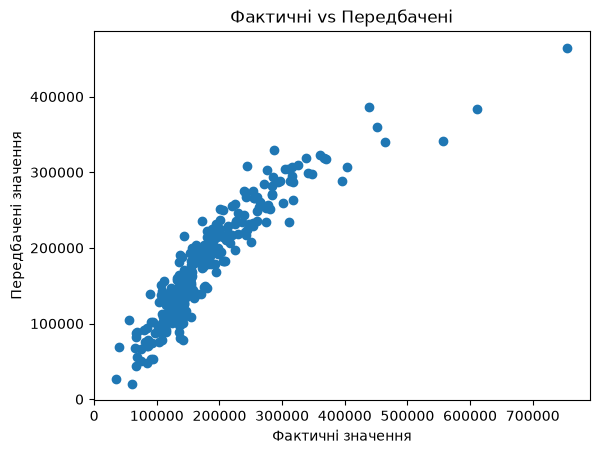

In [18]:
# Передбачення
y_pred = model.predict(X_test)

# Оцінка коефіцієнта детермінації та MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R^2: {r2}")
print(f"MSE: {mse}")

# Побудова графіка
plt.scatter(y_test, y_pred)
plt.xlabel("Фактичні значення")
plt.ylabel("Передбачені значення")
plt.title("Фактичні vs Передбачені")
plt.show()

Результат у вас доволі хороший для базової Linear Regression. Модель уже навчилася відтворювати загальну залежність між характеристиками будинку та його ціною.

У вас отримано:

R² = 0.8227
MSE = 1 396 114 555.66

R² = 0.8227 означає, що модель пояснює приблизно 82,3% варіації ціни будинків за використаними ознаками. Тобто характеристики на кшталт площі, якості, року побудови, гаража тощо досить добре дозволяють передбачити SalePrice.

Чим ближче R² до 1, тим точніше модель описує дані:

R² = 1.0     → практично ідеальний прогноз
R² = 0.82    → хороший результат
R² = 0       → модель майже нічого не пояснює
Що означає MSE
MSE = 1 396 114 555

MSE — середня квадратична помилка. Вона велика за числом тому, що помилки підносяться до квадрату.

Наприклад, якщо модель помилилася на $30 000, то в MSE потрапляє:

30 000² = 900 000 000

Тому MSE не дуже зручно інтерпретувати безпосередньо.

Для практичної роботи раджу додати ще RMSE, бо він буде вимірюватися у тих самих одиницях, що й SalePrice:

import numpy as np

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

Для вашого результату це буде приблизно:

RMSE ≈ 37 000

Тобто типова величина помилки моделі становить приблизно 37 тис. одиниць ціни; для Kaggle House Prices це приблизно долари.

Що показує ваш графік

По горизонтальній осі:

Фактичні значення

тобто реальні ціни будинків.

По вертикальній:

Передбачені значення

тобто ціни, які спрогнозувала модель.

В ідеальному випадку всі точки мали б знаходитися приблизно вздовж уявної діагоналі:

передбачена ціна = фактична ціна

У вас більшість точок розташована досить компактно вздовж цієї діагоналі. Це підтверджує значення R² ≈ 0.82.

Але на графіку видно ще одну цікаву особливість: для дуже дорогих будинків модель часто прогнозує ціну нижче фактичної. Наприклад, для будинку з реальною ціною близько 750 000 прогноз знаходиться приблизно біля 460 000.

Це означає, що проста лінійна модель добре працює для основної маси будинків, але гірше описує крайні, дорогі об'єкти.

Для практичної роботи можете написати такий висновок:

За результатами моделювання коефіцієнт детермінації становив R² = 0,823, що свідчить про здатність побудованої моделі лінійної регресії пояснювати близько 82,3% варіації цільової ознаки SalePrice. Аналіз графіка фактичних і передбачених значень показує достатньо високу відповідність прогнозів реальним значенням для основної частини вибірки. Водночас для окремих об'єктів із високою вартістю спостерігаються значні відхилення, що може свідчити про наявність нелінійних залежностей та викидів у даних.

In [19]:
### Додаткове завдання: Інші алгоритми регресії

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
print(f"Ridge R^2: {r2_score(y_test, ridge_pred)}")

# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
print(f"Lasso R^2: {r2_score(y_test, lasso_pred)}")

# Decision Tree Regressor
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
print(f"Decision Tree R^2: {r2_score(y_test, tree_pred)}")

Ridge R^2: 0.822752450009191
Lasso R^2: 0.8227442918197584
Decision Tree R^2: 0.8027396163062853


порівняли три різні алгоритми регресії, Тобто Linear Regression, Ridge і Lasso дали майже однаковий результат — близько 82,3%, а дерево рішень — близько 80,3%.